In [1]:
import matplotlib.pyplot as plt
from torch import load as torch_load, cat
import h5py
import os
from scanner_modeling._plot._mpl_plot_system import (
    plot_polygons_from_vertices_mpl,
    plot_scanner_from_vertices_2d_mpl,
)
from scanner_modeling.geometry_2d import (
    fov_tensor_dict,
    load_scanner_geometry_from_layout,
    load_scanner_layouts,
)
from scanner_modeling._convex_hull._convex_hull_functions import (
    convex_hull_2d,
    sort_points_for_hull_2d,
)
from scanner_modeling._raytracer_2d._local_functions import (
    sfov_properties,
)
import numpy as np
from numpy.typing import NDArray

In [2]:
scanner_layout_file_relative_path = (
    "scanner_layouts/scanner_layouts_e1531c3444e51439add2f18f5714fc50.tensor"
)

fov_dict = fov_tensor_dict((512, 512), (128, 128), (0.0, 0.0), (8, 8))


layout_idx = 0

scanner_layout_dir = os.path.dirname(scanner_layout_file_relative_path)
scanner_layout_filename = os.path.basename(scanner_layout_file_relative_path)
scanner_layouts, layouts_md5 = load_scanner_layouts(
    scanner_layout_dir,
    scanner_layout_filename,
)
(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(layout_idx, scanner_layouts)
sfov_pxs_ids, sfov_pixels_batch, sfov_corners_batch = sfov_properties(fov_dict)
fov_n_pxs = int(fov_dict["n pixels"].prod())
n_sfov = int(fov_dict["n subdivisions"].prod())
sfov_n_pxs = fov_n_pxs / int(fov_dict["n subdivisions"].prod())
crystal_idx = 160
hull_sfov_list = []
for sfov_idx in range(n_sfov):
    sorted_vertices = sort_points_for_hull_2d(
         cat(
                (
                    sfov_corners_batch[sfov_idx],
                    crystal_objects_vertices[crystal_idx],
                ),
                dim=0,
            )
    )
    local_hull = convex_hull_2d(sorted_vertices)
    hull_sfov_list.append(local_hull)


<KeysViewHDF5 ['ppdfs']>


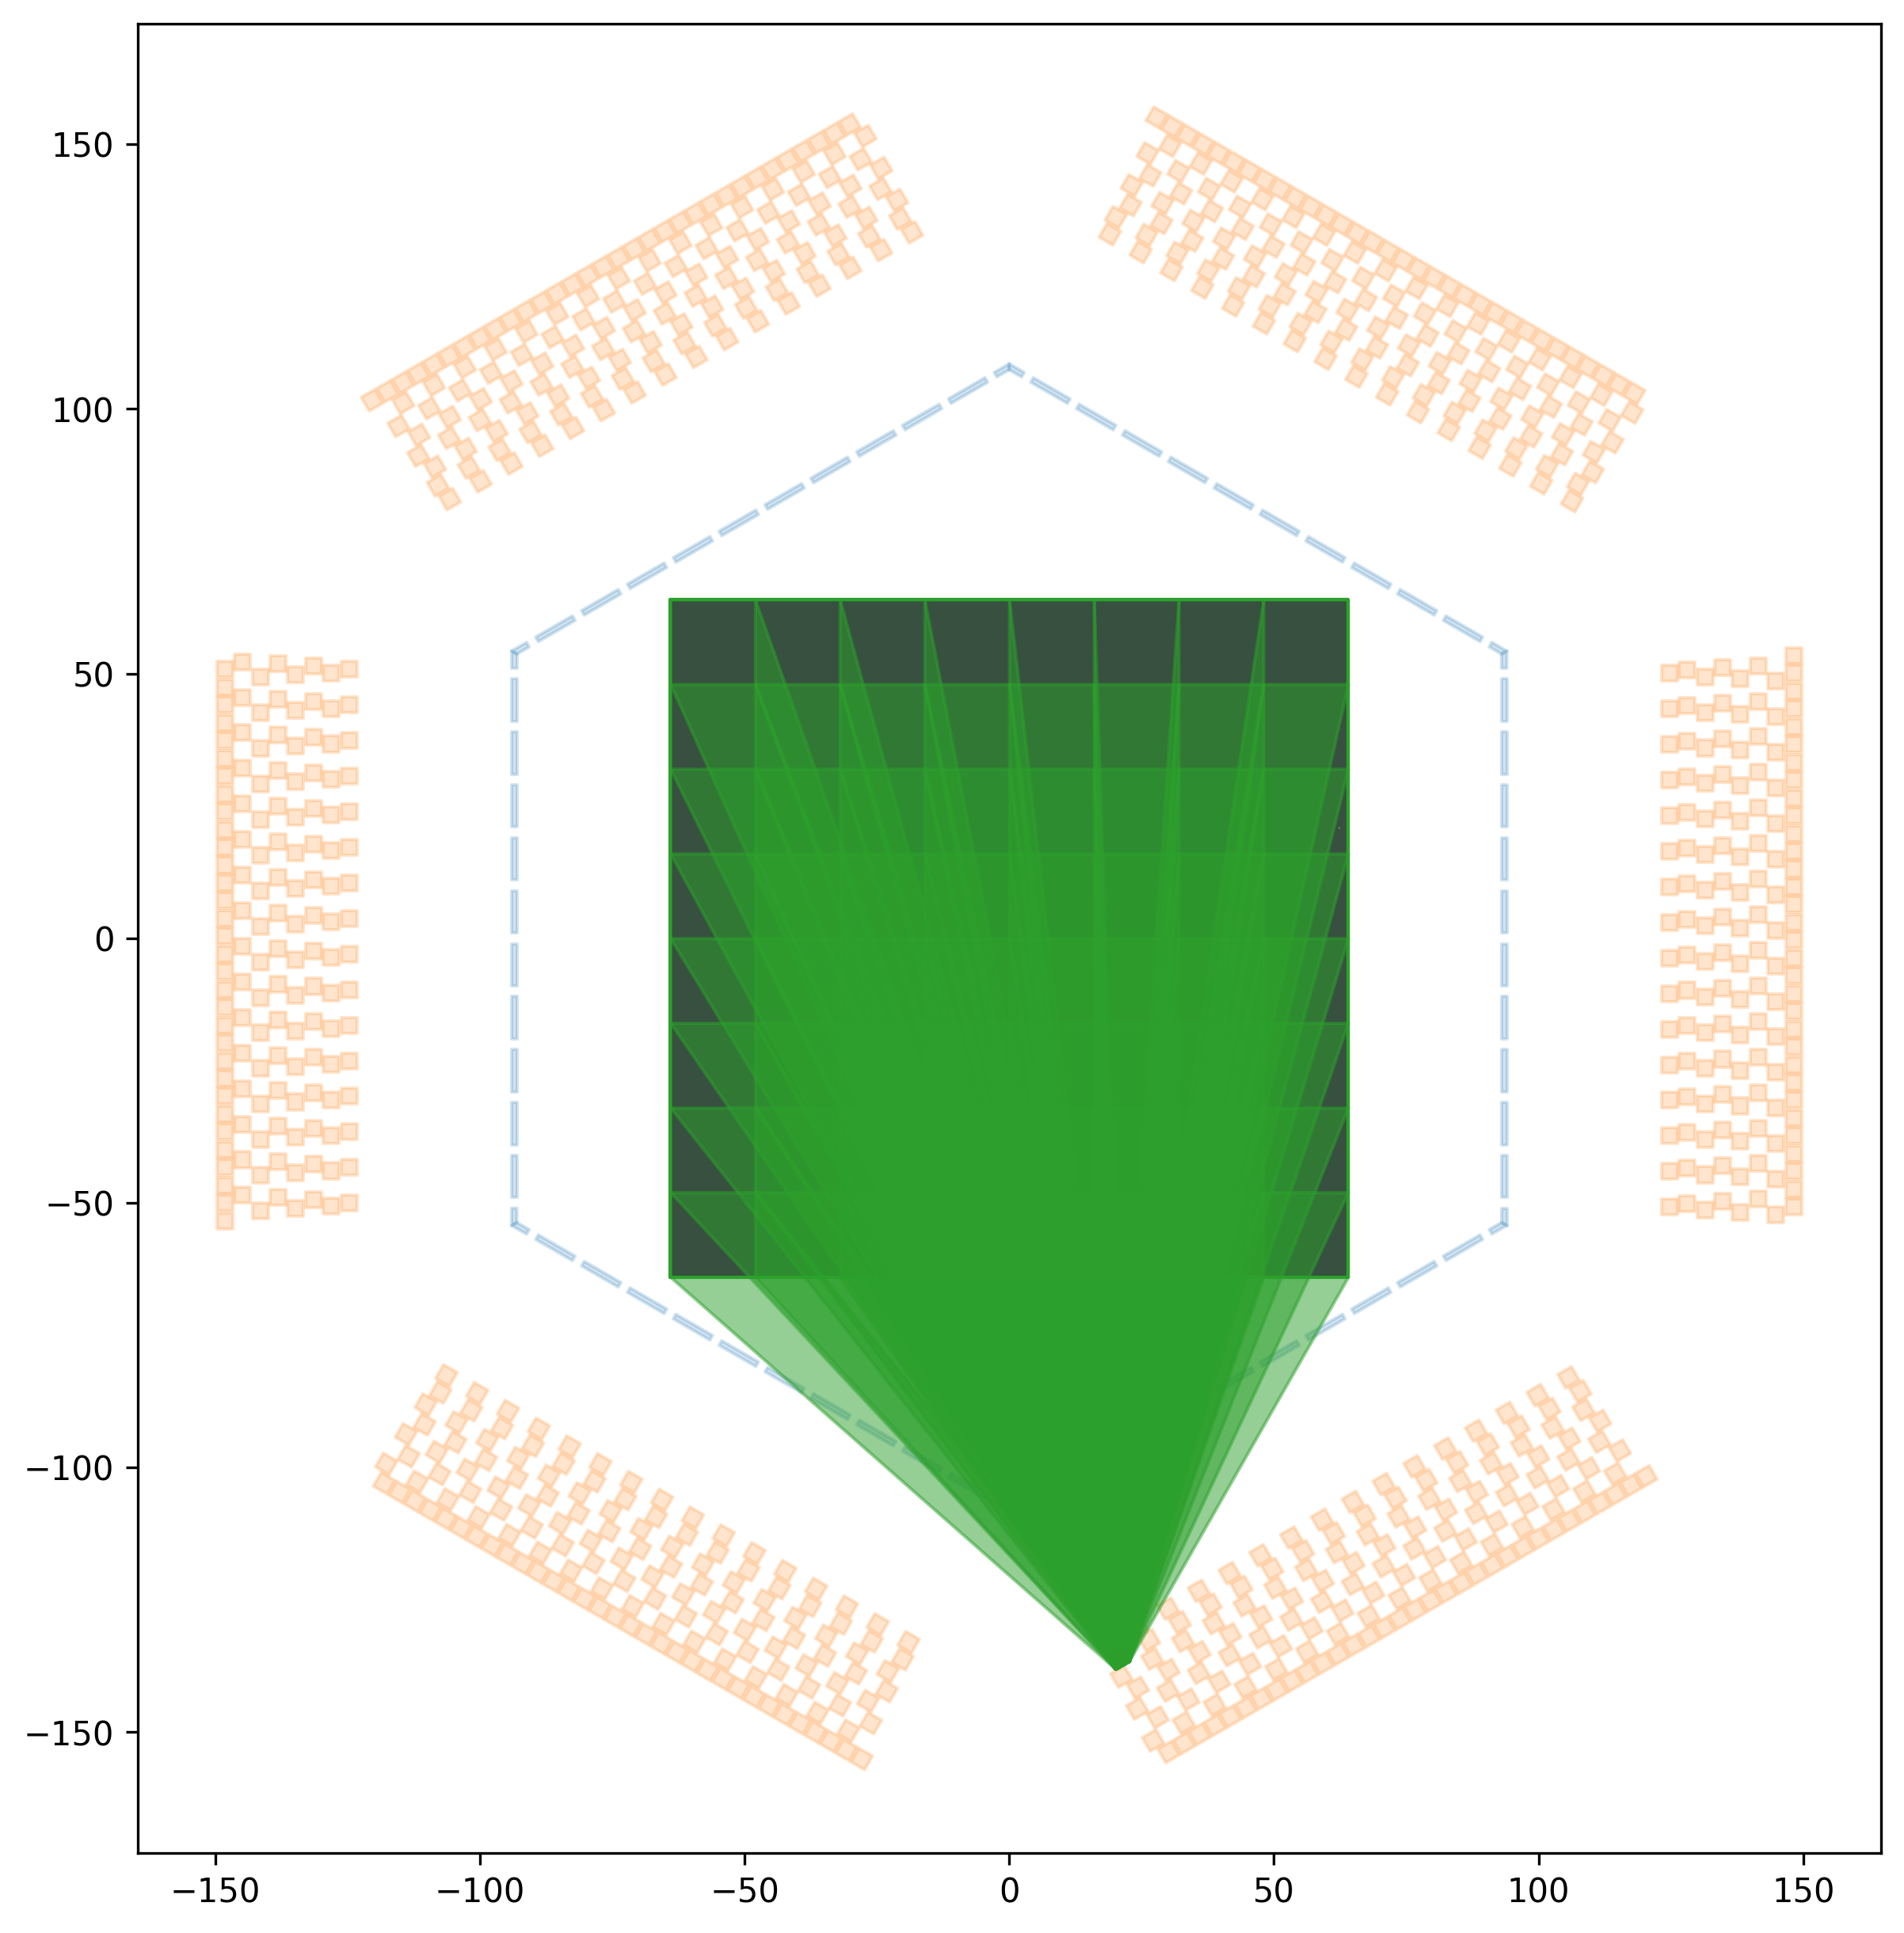

In [ ]:

with h5py.File(
    f"scanner_layouts_e1531c3444e51439add2f18f5714fc50_layout_{layout_idx}.hdf5", "r"
) as input_h5file:
    print(input_h5file.keys())
    ppdfs_dataset: NDArray = np.array(input_h5file["ppdfs"])
    

    # ppdf_data = ppdfs_dataset[0]
    plt.close("all")
    fig, ax = plt.subplots(1, 1, figsize=(10, 10),dpi=300)
    ax.imshow(
        ppdfs_dataset[crystal_idx].reshape(512, 512).T,
        origin="lower",
        interpolation="none",
        extent=(
            -fov_dict["size in mm"][0] * 0.5,
            fov_dict["size in mm"][0] * 0.5,
            -fov_dict["size in mm"][1] * 0.5,
            fov_dict["size in mm"][1] * 0.5,
        ),
    )
    scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
        plate_objects_vertices,
        crystal_objects_vertices,
        ax,
        fov_dict,
        plate_alpha=0.2,
        crystal_alpha=0.2,
        fov_alpha=1,
    )
    selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
        crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
    )
    # for hull_sfov in hull_sfov_list:
    #     plot_polygons_from_vertices_mpl(
    #         hull_sfov.reshape(1, -1, 2), ax, color="C2", alpha=0.5
    #     )

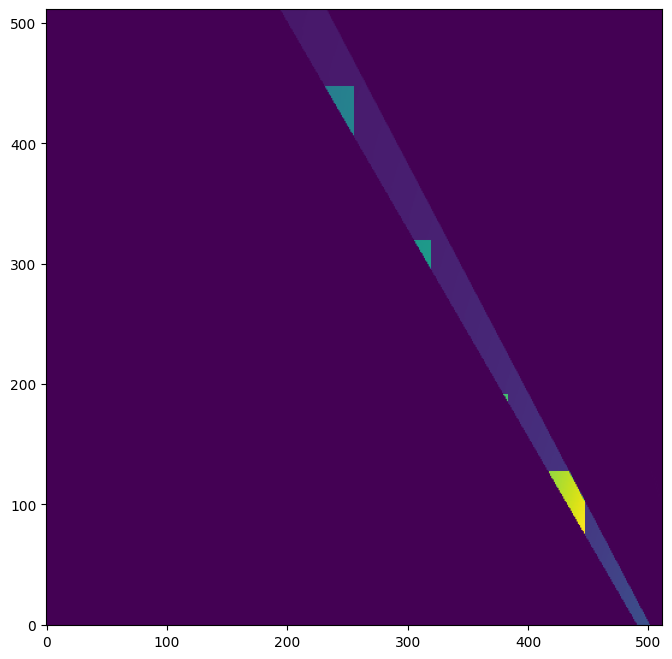

In [3]:
ppdf_data = torch_load('ppdf_234_loop.tensor')
plt.close('all')
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(ppdf_data.view(512,512).T,origin='lower')

KeyError: "Unable to synchronously open object (object 'ppdf' doesn't exist)"